# Notebook 06: Pseudo Label (Gemini Batch API + VietOCR Filter)

## Mục tiêu
- **Stage 1 (đã có sẵn):** dùng kết quả lọc ở `phase1_filtered_candidates.json`.
- **Stage 2 (gán nhãn):** OCR bằng **Gemini Batch API** (File API JSONL) với `gemini-3-flash-preview`, lọc: ≥46 chars, VietOCR vocab, Vietnamese only.
- **Stage 3 (lọc chất lượng):** dùng **VietOCR vgg_transformer** default pretrain, so khớp mềm (Levenshtein ≥ 0.4), xuất `pseudo_labels_final.txt`.

## Ghi chú tối ưu chi phí
- Batch API giảm 50% chi phí so với interactive.
- File API JSONL: ~500 ảnh/batch, ~11 batch jobs.
- Resize + JPEG quality vừa đủ để giảm token ảnh.
- Prompt ngắn, deterministic (`temperature=0.0`).


In [6]:
# Nếu thiếu package (chạy 1 lần):
# %pip install -q google-genai pillow tqdm matplotlib rapidfuzz vietocr

import os
import re
import io
import json
import time
import base64
import unicodedata
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from rapidfuzz.distance import Levenshtein
from tqdm import tqdm


## Setup & cấu hình
Các cell dưới đây để cấu hình môi trường, đường dẫn và hằng số.


In [13]:
# # Khuyến nghị đặt env ngoài notebook (không hardcode key trong mã nguồn).
# # Ví dụ: export GEMINI_API_KEY='your-gemini-api-key'

# # (tuỳ chọn) set nhanh trong notebook cho phiên chạy hiện tại.
# os.environ["GEMINI_API_KEY"] = "..."  # DO NOT COMMIT API KEYS


In [17]:
# ── Gemini API key ──
# GEMINI_API_KEY = os.getenv("GEMINI_API_KEY") or os.getenv("GOOGLE_API_KEY")
# assert GEMINI_API_KEY, "Set GEMINI_API_KEY env var before running"


# ── Paths ──
BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
CRAWLED_DIR = DATA_DIR / "crawled"
CRAWLED_DIR.mkdir(parents=True, exist_ok=True)

# Stage 1 artifacts
PHASE1_FILTERED_JSON = CRAWLED_DIR / "phase1_filtered_candidates.json"

# ── Stage 2 config ──
GEMINI_MODEL = "gemini-2.5-pro"
BATCH_CHUNK_SIZE = 500          # images per batch job
IMAGE_MAX_SIDE = 768            # resize before sending
JPEG_QUALITY = 70               # JPEG compress quality
MIN_LABEL_CHARS = 46            # reject labels < 46 chars
TEMPERATURE = 0.0               # deterministic output

# VietOCR vocab (from base.yml)
VIETOCR_VOCAB_STR = (
    'aAàÀảẢãÃáÁạẠăĂằẰẳẲẵẴắẮặẶâÂầẦẩẨẫẪấẤậẬ'
    'bBcCdDđĐeEèÈẻẺẽẼéÉẹẸêÊềỀểỂễỄếẾệỆ'
    'fFgGhHiIìÌỉỈĩĨíÍịỊjJkKlLmMnNoOòÒỏỎõÕóÓọỌ'
    'ôÔồỒổỔỗỖốỐộỘơƠờỜởỞỡỠớỚợỢpPqQrRsStT'
    'uUùÙủỦũŨúÚụỤưƯừỪửỬữỮứỨựỰvVwWxXyYỳỲỷỶỹỸýÝỵỴ'
    'zZ0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~ '
)
VIETOCR_VOCAB = set(VIETOCR_VOCAB_STR)

# ── Artifact paths ──
PHASE2_RAW_LABELS_JSONL = CRAWLED_DIR / "phase2_raw_labels.jsonl"
PHASE2_BATCH_REGISTRY   = CRAWLED_DIR / "phase2_batch_jobs_registry.json"
PHASE2_LABELS_FILE      = CRAWLED_DIR / "phase2_clean_labels.txt"
PHASE2_SUMMARY_JSON     = CRAWLED_DIR / "phase2_label_summary_gemini.json"

STAGE3_FINAL_LABELS     = CRAWLED_DIR / "pseudo_labels_final_clean.txt"
STAGE3_SUMMARY_JSON     = CRAWLED_DIR / "stage3_filter_summary.json"
STAGE3_HIST_PNG         = CRAWLED_DIR / "stage3_similarity_distribution.png"

# ── Stage 3 threshold ──
STAGE3_THRESHOLD = 0.7

# ── OCR prompt ──
OCR_PROMPT = (
    "Đọc chính xác toàn bộ chữ viết tay tiếng Việt trong ảnh này. "
    "Chỉ trả về nội dung text thuần, không giải thích, không thêm gì khác."
)

print("Config loaded.")
print(f"  Model:          {GEMINI_MODEL}")
print(f"  Chunk size:     {BATCH_CHUNK_SIZE}")
print(f"  Min label len:  {MIN_LABEL_CHARS}")
print(f"  S3 threshold:   {STAGE3_THRESHOLD}")
print(f"  VietOCR vocab:  {len(VIETOCR_VOCAB)} chars")


Config loaded.
  Model:          gemini-2.5-pro
  Chunk size:     500
  Min label len:  46
  S3 threshold:   0.7
  VietOCR vocab:  229 chars


## Helpers


In [3]:
def read_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def write_jsonl(records, path):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")


def resize_and_encode_image(img_path: str, max_side: int = 768, quality: int = 70) -> str:
    """Resize image, convert to JPEG, return base64 string."""
    with Image.open(img_path) as im:
        im = im.convert("RGB")
        w, h = im.size
        if max(w, h) > max_side:
            scale = max_side / max(w, h)
            im = im.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
        buf = io.BytesIO()
        im.save(buf, format="JPEG", quality=quality)
        return base64.b64encode(buf.getvalue()).decode("utf-8")


def is_valid_label(label: str) -> Tuple[bool, str]:
    """Check if label passes Stage 2 quality filters."""
    label = unicodedata.normalize('NFC', label).strip()

    if not label:
        return False, "empty"

    if len(label) < MIN_LABEL_CHARS:
        return False, "too_short"

    # Check all chars in VietOCR vocab
    bad_chars = set(label) - VIETOCR_VOCAB
    if bad_chars:
        return False, "non_vocab_chars"

    # Detect non-Vietnamese scripts
    for ch in label:
        cp = ord(ch)
        if (0x4E00 <= cp <= 0x9FFF or     # CJK Unified
            0x3400 <= cp <= 0x4DBF or      # CJK Ext A
            0x0400 <= cp <= 0x04FF or      # Cyrillic
            0x0600 <= cp <= 0x06FF or      # Arabic
            0x0E00 <= cp <= 0x0E7F or      # Thai
            0x3040 <= cp <= 0x30FF or      # Japanese Kana
            0xAC00 <= cp <= 0xD7AF):       # Korean Hangul
            return False, "non_vietnamese_script"

    return True, "ok"


def soft_match_score(gemini_label: str, vietocr_pred: str) -> float:
    """Normalized Levenshtein similarity. 1.0 = identical."""
    if not gemini_label and not vietocr_pred:
        return 1.0
    max_len = max(len(gemini_label), len(vietocr_pred))
    if max_len == 0:
        return 1.0
    dist = Levenshtein.distance(gemini_label, vietocr_pred)
    return 1.0 - dist / max_len


print("Helpers loaded.")


Helpers loaded.


## Stage 1 — Lọc dữ liệu bằng xAI (Grok-4)
Đoạn mã gốc của khang dùng bộ lọc grok-4 để xử lý Phase 1, lọc tỷ lệ dính chữ và rác hình ảnh.
Vì đã xử lý xong nên hệ thống sẽ phát hiện `done already` (9187 ảnh) và lấy trực tiếp kết quả `5103` ảnh mà không tốn phí chạy lại.

In [ ]:
# -------- Paths --------
import os, json, hashlib, time, base64, io, re
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, List, Tuple, Iterable
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError

# Assume XAI SDK is xai_sdk or similar. We will just import what was given:
try:
    from xai_sdk import Client, system, user, image
except ImportError:
    pass # Pseudo-code import for the provided snippet context

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
CRAWLED_DIR = DATA_DIR / "crawled"
DETECTED_LINES_DIR = CRAWLED_DIR / "detected_lines"
VALID_CROPS_PATH = CRAWLED_DIR / "valid_line_crops.json"

# Outputs (phase artifacts)
PHASE1_RESULTS_JSONL = CRAWLED_DIR / "phase1_filter_results.jsonl"
PHASE1_FILTERED_JSON = CRAWLED_DIR / "phase1_filtered_candidates.json"
PHASE1_FAILED_JSONL = CRAWLED_DIR / "phase1_filter_failed.jsonl"
PHASE1_SUMMARY_JSON = CRAWLED_DIR / "phase1_filter_summary.json"

# -------- API + model config --------
XAI_API_KEY = os.getenv("XAI_API_KEY") 
# if not XAI_API_KEY:
#     raise RuntimeError("Thiếu XAI_API_KEY. Hãy export biến môi trường trước khi chạy notebook.")

PHASE1_MODEL = os.getenv("PHASE1_MODEL", "grok-4")

# Prompt caching key (ổn định theo phase để tăng cache hit)
PHASE1_CONV_ID = os.getenv("PHASE1_CONV_ID", "pseudo-label-phase1-v1")

# -------- Batch settings --------
BATCH_ADD_CHUNK_SIZE = int(os.getenv("BATCH_ADD_CHUNK_SIZE", "64"))
POLL_SECONDS = int(os.getenv("POLL_SECONDS", "15"))
SAMPLE_SIZE = None

# -------- Phase 1 filters --------
SPLIT_THRESHOLD = 15
PHASE1_IMAGE_MAX_SIDE = 768
PHASE1_JPEG_QUALITY = 65
PHASE1_IMAGE_DETAIL = "low"

print("✓ BASE_DIR:", BASE_DIR)
print("✓ DETECTED_LINES_DIR:", DETECTED_LINES_DIR)
print("✓ PHASE1_MODEL:", PHASE1_MODEL)

PHASE1_SYSTEM_PROMPT = (
    "Bạn là bộ lọc dữ liệu OCR handwriting tiếng Việt. "
    "Hãy đánh giá đúng 1 ảnh line-crop và chỉ trả JSON minified, không markdown. "
    "Schema bắt buộc: "
    "{\"is_handwritten\":true|false,\"spill_pct\":0-100,\"keep\":true|false,\"confidence\":0.0-1.0}. "
    "spill_pct là phần trăm chữ bị dính từ dòng trên/dưới (0 = sạch hoàn toàn). "
    "keep=true CHỈ khi: line chính là chữ viết tay thuần + spill_pct < 15 (tức là gần như không dính)."
    "Trả về JSON hợp lệ, không thêm bất kỳ chữ nào ngoài JSON object."
)

PHASE1_USER_PROMPT = "Đánh giá ảnh này theo schema yêu cầu."

def stable_request_id(prefix: str, image_path: str) -> str:
    h = hashlib.sha1(image_path.encode("utf-8")).hexdigest()[:16]
    return f"{prefix}_{h}"

def chunked(items: List[str], chunk_size: int) -> Iterable[List[str]]:
    for i in range(0, len(items), chunk_size):
        yield items[i:i + chunk_size]

def read_jsonl(path: Path) -> List[Dict[str, Any]]:
    if not path.exists():
        return []
    records: List[Dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def append_jsonl(path: Path, records: List[Dict[str, Any]]) -> None:
    if not records:
        return
    with path.open("a", encoding="utf-8") as f:
        for record in records:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")

def load_candidate_paths(valid_crops_path: Path, detected_lines_dir: Path, sample_size: int | None = None) -> List[str]:
    if valid_crops_path.exists():
        raw_paths = json.loads(valid_crops_path.read_text(encoding="utf-8"))
        paths = [str(Path(p).resolve()) for p in raw_paths]
    else:
        paths = [str(p.resolve()) for p in sorted(detected_lines_dir.glob("*.jpg"))]
    paths = [p for p in paths if Path(p).exists()]
    paths = sorted(set(paths))
    if sample_size is not None:
        paths = paths[:sample_size]
    return paths

def prefilter_geometry(paths: List[str]) -> Tuple[List[str], List[Dict[str, Any]]]:
    kept: List[str] = []
    dropped: List[Dict[str, Any]] = []
    for p in tqdm(paths, desc="Local prefilter"):
        try:
            with Image.open(p) as im:
                w, h = im.size
        except (UnidentifiedImageError, OSError):
            dropped.append({"image_path": p, "reason": "invalid_image"})
            continue
        if w < 80 or h < 18:
            dropped.append({"image_path": p, "reason": "too_small", "w": w, "h": h})
            continue
        aspect = w / max(h, 1)
        if aspect < 2.0 or aspect > 35.0:
            dropped.append({"image_path": p, "reason": "bad_aspect", "w": w, "h": h, "aspect": aspect})
            continue
        kept.append(p)
    return kept, dropped

def image_to_data_uri(image_path: str, max_side: int, jpeg_quality: int) -> str:
    with Image.open(image_path) as im:
        im = im.convert("RGB")
        w, h = im.size
        long_side = max(w, h)
        if long_side > max_side:
            scale = max_side / long_side
            new_size = (max(1, int(w * scale)), max(1, int(h * scale)))
            im = im.resize(new_size, Image.LANCZOS)
        buf = io.BytesIO()
        im.save(buf, format="JPEG", quality=jpeg_quality, optimize=True)
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/jpeg;base64,{b64}"

def response_text(content: Any) -> str:
    if isinstance(content, str):
        return content.strip()
    if isinstance(content, list):
        parts: List[str] = []
        for item in content:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict) and "text" in item:
                parts.append(str(item["text"]))
            elif hasattr(item, "text"):
                parts.append(str(item.text))
        return "\n".join(parts).strip()
    if hasattr(content, "text"):
        return str(content.text).strip()
    return str(content).strip()

def extract_json_object(text: str) -> Dict[str, Any]:
    s = text.strip()
    start = s.find("{")
    end = s.rfind("}")
    if start == -1 or end == -1 or end <= start:
        raise ValueError(f"Không tìm thấy JSON object hợp lệ: {text[:120]}")
    return json.loads(s[start:end + 1])

def parse_float(value: Any, default: float = 0.0) -> float:
    if isinstance(value, (int, float)):
        return float(value)
    if isinstance(value, str):
        return float(value.strip())
    return default

def parse_int(value: Any, default: int = -1) -> int:
    if isinstance(value, int):
        return value
    if isinstance(value, float):
        return int(round(value))
    if isinstance(value, str):
        return int(round(float(value.strip())))
    return default

def build_client(conv_id: str) -> Any:
    return Client(api_key=XAI_API_KEY, metadata=(("x-grok-conv-id", conv_id),))

def wait_for_batch(client: Any, batch_id: str, poll_seconds: int = 15):
    while True:
        batch = client.batch.get(batch_id=batch_id)
        state = batch.state
        done = state.num_success + state.num_error + state.num_cancelled
        total = state.num_requests
        print(f"Batch {batch_id}: {done}/{total} done | pending={state.num_pending}")
        if state.num_pending == 0:
            return batch
        time.sleep(poll_seconds)

def collect_batch_results(client: Any, batch_id: str, page_size: int = 100):
    succeeded = []
    failed = []
    pagination_token = None
    while True:
        page = client.batch.list_batch_results(
            batch_id=batch_id,
            limit=page_size,
            pagination_token=pagination_token,
        )
        succeeded.extend(page.succeeded)
        failed.extend(page.failed)
        if page.pagination_token is None:
            break
        pagination_token = page.pagination_token
    return succeeded, failed

def aggregate_usage(results: List[Any]) -> Dict[str, int]:
    total = {
        "prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0,
        "cached_tokens": 0, "image_tokens": 0, "text_tokens": 0,
    }
    for r in results:
        usage = getattr(r.response, "usage", None)
        if usage is None: continue
        total["prompt_tokens"] += int(getattr(usage, "prompt_tokens", 0))
        total["completion_tokens"] += int(getattr(usage, "completion_tokens", 0))
        total["total_tokens"] += int(getattr(usage, "total_tokens", 0))
        details = getattr(usage, "prompt_tokens_details", None)
        if details is not None:
            total["cached_tokens"] += int(getattr(details, "cached_tokens", 0))
            total["image_tokens"] += int(getattr(details, "image_tokens", 0))
            total["text_tokens"] += int(getattr(details, "text_tokens", 0))
    return total

def ticks_to_usd(ticks: int) -> float:
    return ticks / 1e10 

In [7]:
# -------- Run Phase 1 --------
all_candidates = load_candidate_paths(VALID_CROPS_PATH, DETECTED_LINES_DIR, SAMPLE_SIZE)
prefiltered_candidates, local_drop = prefilter_geometry(all_candidates)

print(f"Candidates loaded: {len(all_candidates)}")
print(f"After local prefilter: {len(prefiltered_candidates)}")
print(f"Dropped locally: {len(local_drop)}")

existing_phase1 = read_jsonl(PHASE1_RESULTS_JSONL)
done_paths_phase1 = {r["image_path"] for r in existing_phase1 if "image_path" in r}
pending_phase1 = [p for p in prefiltered_candidates if p not in done_paths_phase1]

print(f"Phase1 done already: {len(done_paths_phase1)}")
print(f"Phase1 pending: {len(pending_phase1)}")

phase1_batch_id = None
phase1_usage = None
phase1_cost_usd = 0.0

if pending_phase1 and XAI_API_KEY:
    client_p1 = build_client(PHASE1_CONV_ID)
    phase1_batch = client_p1.batch.create(batch_name=f"pseudo_phase1_{datetime.now().strftime(%Y%m%d_%H%M%S)}")
    phase1_batch_id = phase1_batch.batch_id

    req_map: Dict[str, str] = {}
    for group in tqdm(list(chunked(pending_phase1, BATCH_ADD_CHUNK_SIZE)), desc="Submit phase1"):
        requests = []
        for p in group:
            rid = stable_request_id("p1", p)
            req_map[rid] = p
            data_uri = image_to_data_uri(p, PHASE1_IMAGE_MAX_SIDE, PHASE1_JPEG_QUALITY)

            chat = client_p1.chat.create(model=PHASE1_MODEL, batch_request_id=rid)
            chat.append(system(PHASE1_SYSTEM_PROMPT))
            chat.append(user(PHASE1_USER_PROMPT, image(image_url=data_uri, detail=PHASE1_IMAGE_DETAIL)))
            requests.append(chat)

        client_p1.batch.add(batch_id=phase1_batch_id, batch_requests=requests)

    print("Phase1 batch_id:", phase1_batch_id)
    finished_p1 = wait_for_batch(client_p1, phase1_batch_id, POLL_SECONDS)
    succ_p1, fail_p1 = collect_batch_results(client_p1, phase1_batch_id, page_size=200)

    phase1_usage = aggregate_usage(succ_p1)
    cost_ticks = int(getattr(getattr(finished_p1, "cost_breakdown", None), "total_cost_usd_ticks", 0))
    phase1_cost_usd = ticks_to_usd(cost_ticks)

    succ_ids = {r.batch_request_id for r in succ_p1}
    fail_ids = {r.batch_request_id for r in fail_p1}
    all_ids = set(req_map.keys())
    missing_ids = sorted(all_ids - succ_ids - fail_ids)

    print("succ:", len(succ_ids), "fail:", len(fail_ids), "missing:", len(missing_ids))

    phase1_records: List[Dict[str, Any]] = []
    for res in succ_p1:
        rid = res.batch_request_id
        img_path = req_map.get(rid, "")
        raw = response_text(res.response.content)

        record: Dict[str, Any] = {
            "request_id": rid,
            "image_path": img_path,
            "raw_response": raw,
            "status": "ok",
        }

        try:
            obj = extract_json_object(raw)
            is_handwritten = bool(obj.get("is_handwritten", False))
            spill_pct = parse_int(obj.get("spill_pct", -1), default=-1)
            confidence = parse_float(obj.get("confidence", 0.0), default=0.0)

            keep = bool(is_handwritten and spill_pct < SPLIT_THRESHOLD)
            record.update({"is_handwritten": is_handwritten, "spill_pct": spill_pct, "confidence": confidence, "keep": keep})
        except (ValueError, json.JSONDecodeError) as e:
            record.update({"status": "parse_error", "error": str(e), "keep": False})

        phase1_records.append(record)

    phase1_fail_records = [
        {"request_id": r.batch_request_id, "status": "failed", "error_message": getattr(r, "error_message", ""), "image_path": req_map.get(r.batch_request_id, "")}
        for r in fail_p1
    ]
    phase1_fail_records += [
        {"request_id": rid, "status": "pending_timeout", "error_message": "stuck_pending", "image_path": req_map[rid]}
        for rid in missing_ids
    ]

    append_jsonl(PHASE1_RESULTS_JSONL, phase1_records)
    append_jsonl(PHASE1_FAILED_JSONL, phase1_fail_records)
    print("saved:", len(phase1_records), "ok records |", len(phase1_fail_records), "failed/pending records")
else:
    print("Phase1 không gọi API (hoặc thiếu XAI_API_KEY / không có ảnh pending), dùng kết quả đã có.")

all_phase1 = read_jsonl(PHASE1_RESULTS_JSONL)
filtered_phase1 = [r["image_path"] for r in all_phase1 if r.get("status") == "ok" and r.get("keep") is True]

PHASE1_FILTERED_JSON.write_text(json.dumps(filtered_phase1, ensure_ascii=False, indent=2), encoding="utf-8")

summary_p1 = {
    "batch_id": phase1_batch_id,
    "total_candidates": len(all_candidates),
    "after_local_prefilter": len(prefiltered_candidates),
    "local_drop": len(local_drop),
    "phase1_total_records": len(all_phase1),
    "phase1_kept": len(filtered_phase1),
    "split_threshold": SPLIT_THRESHOLD,
    "phase1_cost_usd": phase1_cost_usd,
    "phase1_usage": phase1_usage,
}
PHASE1_SUMMARY_JSON.write_text(json.dumps(summary_p1, ensure_ascii=False, indent=2), encoding="utf-8")

print("\n--- Phase 1 summary ---")
print("Filtered images:", len(filtered_phase1))
print("Saved:", PHASE1_FILTERED_JSON)
if phase1_usage is not None:
    cached = phase1_usage.get("cached_tokens", 0)
    prompt = max(1, phase1_usage.get("prompt_tokens", 1))
    print(f"Cached prompt ratio: {cached / prompt:.2%}")
    print(f"Phase1 estimated cost: ${phase1_cost_usd:.4f}")


Candidates loaded: 9187
After local prefilter: 9187
Dropped locally: 0
Phase1 không gọi API (hoặc thiếu XAI_API_KEY / không có ảnh pending), dùng kết quả đã có.

--- Phase 1 summary ---
Filtered images: 5103
Saved: data/crawled/phase1_filtered_candidates.json
Phase1 estimated cost: $42.8094


# ── Stage 2a: Cleanup old batch jobs + artifacts ──

In [17]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)

# # Cancel any existing pending batch jobs
# if PHASE2_BATCH_REGISTRY.exists():
#     try:
#         old_registry = json.loads(PHASE2_BATCH_REGISTRY.read_text(encoding="utf-8"))
#         for job_entry in old_registry:
#             job_name = job_entry.get("job_name", "")
#             try:
#                 job = client.batches.get(name=job_name)
#                 if job.state.name in ("JOB_STATE_PENDING", "JOB_STATE_RUNNING"):
#                     client.batches.cancel(name=job_name)
#                     print(f"  Cancelled: {job_name}")
#             except Exception as e:
#                 print(f"  Error skipping/cancelling {job_name}: {e}")
#     except Exception as e:
#         print(f"  Error reading registry: {e}")

# # Remove old artifacts
# for old_file in [
#     PHASE2_RAW_LABELS_JSONL, PHASE2_BATCH_REGISTRY,
#     PHASE2_LABELS_FILE, PHASE2_SUMMARY_JSON,
#     STAGE3_FINAL_LABELS, STAGE3_SUMMARY_JSON, STAGE3_HIST_PNG,
# ]:
#     if old_file.exists():
#         old_file.unlink()
#         print(f"  Removed: {old_file.name}")

# print("✓ Cleanup done. Starting fresh.")


In [36]:
# ── Stage 2b: Prepare JSONL, upload to File API, create batch jobs ──

# Ensure fresh list
filtered_phase1 = json.loads(PHASE1_FILTERED_JSON.read_text(encoding="utf-8"))
filtered_phase1 = sorted(set(p for p in filtered_phase1 if Path(p).exists()))
print(f"Stage 1 images: {len(filtered_phase1)}")

# Split into chunks
chunks = [
    filtered_phase1[i : i + BATCH_CHUNK_SIZE]
    for i in range(0, len(filtered_phase1), BATCH_CHUNK_SIZE)
]
print(f"Chunks: {len(chunks)} (chunk_size={BATCH_CHUNK_SIZE})")

batch_registry = []

for chunk_idx, chunk_paths in enumerate(chunks, 1):
    print(f"\n--- Chunk {chunk_idx}/{len(chunks)} ({len(chunk_paths)} images) ---")

    # 1) Create JSONL file
    jsonl_path = CRAWLED_DIR / f"batch_chunk_{chunk_idx:03d}.jsonl"
    encoded_count = 0
    with open(jsonl_path, "w", encoding="utf-8") as f:
        for img_path in tqdm(chunk_paths, desc=f"Encoding chunk {chunk_idx}"):
            img_key = Path(img_path).stem
            try:
                b64_data = resize_and_encode_image(img_path, IMAGE_MAX_SIDE, JPEG_QUALITY)
            except Exception as e:
                print(f"  Skip {Path(img_path).name}: {e}")
                continue

            request_line = {
                "key": img_key,
                "request": {
                    "contents": [{
                        "parts": [
                            {"inline_data": {"mime_type": "image/jpeg", "data": b64_data}},
                            {"text": OCR_PROMPT},
                        ]
                    }],
                    "generation_config": {"temperature": TEMPERATURE},
                },
            }
            f.write(json.dumps(request_line, ensure_ascii=False) + "\n")
            encoded_count += 1

    file_size_mb = jsonl_path.stat().st_size / (1024 * 1024)
    print(f"  JSONL: {jsonl_path.name} ({file_size_mb:.1f} MB, {encoded_count} requests)")

    # 2) Upload to File API
    display_name = f"pseudo-phase2-chunk-{chunk_idx:03d}-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
    uploaded_file = client.files.upload(
        file=str(jsonl_path),
        config=types.UploadFileConfig(display_name=display_name, mime_type='jsonl'),
    )
    print(f"  Uploaded: {uploaded_file.name}")

    # 3) Create batch job
    batch_job = client.batches.create(
        model=GEMINI_MODEL,
        src=uploaded_file.name,
        config={"display_name": display_name},
    )
    print(f"  Batch job: {batch_job.name} (state={batch_job.state.name})")

    # 4) Register
    batch_registry.append({
        "job_name": batch_job.name,
        "display_name": display_name,
        "chunk_index": chunk_idx,
        "image_paths": chunk_paths,
        "uploaded_file": uploaded_file.name,
        "state": batch_job.state.name,
        "collected": False,
        "submitted_at": datetime.now().isoformat(),
    })

    # Save registry after each submission (resume-safe)
    PHASE2_BATCH_REGISTRY.write_text(
        json.dumps(batch_registry, ensure_ascii=False, indent=2), encoding="utf-8"
    )

    # Cleanup local JSONL (already uploaded)
    jsonl_path.unlink()

    time.sleep(2)  # small delay between submissions

print(f"\n✓ All {len(chunks)} batch jobs submitted.")
print(f"  Registry: {PHASE2_BATCH_REGISTRY}")


Stage 1 images: 5103
Chunks: 11 (chunk_size=500)

--- Chunk 1/11 (500 images) ---


Encoding chunk 1: 100%|██████████| 500/500 [00:00<00:00, 846.99it/s]


  JSONL: batch_chunk_001.jsonl (3.3 MB, 500 requests)
  Uploaded: files/ux8evh7ij45j
  Batch job: batches/v139w0o23bb582qk1yu4qrvna7k6b46alq7o (state=JOB_STATE_PENDING)

--- Chunk 2/11 (500 images) ---


Encoding chunk 2: 100%|██████████| 500/500 [00:00<00:00, 903.98it/s] 


  JSONL: batch_chunk_002.jsonl (3.5 MB, 500 requests)
  Uploaded: files/j9uflpbsn9pe
  Batch job: batches/h6rahw6u4e1nhfnky2yiep9g8g6ihht9pb4h (state=JOB_STATE_PENDING)

--- Chunk 3/11 (500 images) ---


...

Encoding chunk 10: 100%|██████████| 500/500 [00:00<00:00, 1198.40it/s]


  JSONL: batch_chunk_010.jsonl (3.4 MB, 500 requests)
  Uploaded: files/ibqojva4akru
  Batch job: batches/a5mmqjldyxjpkur9l5jxxsc2gilvuh9cus7e (state=JOB_STATE_PENDING)

--- Chunk 11/11 (103 images) ---


Encoding chunk 11: 100%|██████████| 103/103 [00:00<00:00, 1178.68it/s]

  JSONL: batch_chunk_011.jsonl (0.7 MB, 103 requests)


  Uploaded: files/scv1kgmrl4gk
  Batch job: batches/wp2p8bu89224sknuaj4a73h1wcrh8f1x4g7c (state=JOB_STATE_PENDING)

✓ All 11 batch jobs submitted.
  Registry: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/phase2_batch_jobs_registry.json


In [ ]:
# ── Stage 2c (RESUME): Poll + Collect ──
# Chạy cell này thay vì cell cũ. Sẽ tự detect jobs đã succeeded.

import json, time, math
from pathlib import Path
from datetime import datetime

# Reload từ disk — lấy state mới nhất
batch_registry = json.loads(PHASE2_BATCH_REGISTRY.read_text(encoding="utf-8"))

COMPLETED_STATES = {
    'JOB_STATE_SUCCEEDED', 'JOB_STATE_FAILED',
    'JOB_STATE_CANCELLED', 'JOB_STATE_EXPIRED',
}
TRANSIENT_CODES = {503, 429, 500}
POLL_INTERVAL_S = 30  # nhanh hơn vì gần xong

error_counts = {e['job_name']: 0 for e in batch_registry}
poll_start = time.time()

pre_ok = sum(1 for e in batch_registry if e['state'] == 'JOB_STATE_SUCCEEDED')
pre_todo = sum(1 for e in batch_registry if e['state'] not in COMPLETED_STATES)
print(f"Resume polling | Already succeeded={pre_ok} | Still pending={pre_todo} | interval={POLL_INTERVAL_S}s")

while True:
    pending = 0
    running = 0
    errors_this_round = []

    for entry in batch_registry:
        job_name = entry['job_name']
        if entry['state'] in COMPLETED_STATES:
            continue

        err_cnt = error_counts.get(job_name, 0)
        if err_cnt > 0:
            backoff = min(30 * (2 ** (err_cnt - 1)), 300)
            last_check = entry.get('last_checked_at', '')
            if last_check:
                elapsed = (datetime.now() - datetime.fromisoformat(last_check)).total_seconds()
                if elapsed < backoff:
                    pending += 1
                    continue

        for attempt in range(5):
            try:
                job = client.batches.get(name=job_name)
                entry['state'] = job.state.name
                entry['last_checked_at'] = datetime.now().isoformat()
                error_counts[job_name] = 0
                break
            except Exception as e:
                err_str = str(e)
                is_transient = any(str(c) in err_str for c in TRANSIENT_CODES)
                if is_transient and attempt < 4:
                    time.sleep(5 * (attempt + 1))
                    continue
                if error_counts.get(job_name, 0) == 0:
                    errors_this_round.append(f"  ⚠ {job_name.split('/')[-1][:20]}: {err_str[:100]}")
                error_counts[job_name] = error_counts.get(job_name, 0) + 1
                break

        if entry['state'] == 'JOB_STATE_RUNNING':
            running += 1
            pending += 1
        elif entry['state'] not in COMPLETED_STATES:
            pending += 1

    PHASE2_BATCH_REGISTRY.write_text(
        json.dumps(batch_registry, ensure_ascii=False, indent=2), encoding='utf-8'
    )

    succeeded = sum(1 for e in batch_registry if e['state'] == 'JOB_STATE_SUCCEEDED')
    failed = sum(1 for e in batch_registry if e['state'] in COMPLETED_STATES - {'JOB_STATE_SUCCEEDED'})
    total_errors = sum(error_counts.values())

    status_line = f"  [{datetime.now().strftime('%H:%M:%S')}] Succeeded: {succeeded}, Running: {running}, Pending: {pending - running}, Failed: {failed}"
    if total_errors:
        status_line += f" (errs={total_errors})"
    print(status_line)

    for err in errors_this_round:
        print(err)

    if pending == 0:
        break

    time.sleep(POLL_INTERVAL_S)

print(f"\n✓ All jobs done. Succeeded: {succeeded}, Failed: {failed}")

# ── Collect results ──
all_raw_results = []

for entry in batch_registry:
    if entry["state"] != "JOB_STATE_SUCCEEDED":
        print(f"  Skip chunk {entry['chunk_index']} (state={entry['state']})")
        continue
    if entry.get("collected"):
        print(f"  Chunk {entry['chunk_index']}: already collected, skip")
        continue

    print(f"  Collecting chunk {entry['chunk_index']}...")
    try:
        job = client.batches.get(name=entry["job_name"])
        key_to_path = {Path(p).stem: p for p in entry["image_paths"]}

        if job.dest and job.dest.file_name:
            file_content = client.files.download(file=job.dest.file_name)
            chunk_results = []
            for line in file_content.decode('utf-8').splitlines():
                if not line.strip():
                    continue
                parsed = json.loads(line)
                key = parsed.get("key", "")
                img_path = key_to_path.get(key, "")
                text = ""
                if "response" in parsed and parsed["response"]:
                    try:
                        cands = parsed["response"]["candidates"]
                        parts = cands[0]["content"]["parts"]
                        text = "".join(p.get("text", "") for p in parts)
                    except (KeyError, IndexError):
                        pass
                chunk_results.append({
                    "key": key, "image_path": img_path,
                    "gemini_label": text.strip(), "chunk_index": entry["chunk_index"],
                })
            all_raw_results.extend(chunk_results)
            print(f"    ✓ {len(chunk_results)} results")

        elif job.dest and job.dest.inlined_responses:
            chunk_results = []
            for i, resp in enumerate(job.dest.inlined_responses):
                img_path = entry["image_paths"][i] if i < len(entry["image_paths"]) else ""
                key = Path(img_path).stem if img_path else f"inline_{i}"
                text = ""
                if resp.response:
                    try:
                        text = resp.response.text
                    except Exception:
                        pass
                chunk_results.append({
                    "key": key, "image_path": img_path,
                    "gemini_label": text.strip() if text else "",
                    "chunk_index": entry["chunk_index"],
                })
            all_raw_results.extend(chunk_results)
            print(f"    ✓ {len(chunk_results)} results (inline)")

        else:
            print(f"    ⚠ No output for chunk {entry['chunk_index']}")

        entry["collected"] = True
    except Exception as e:
        print(f"    ✗ Error chunk {entry['chunk_index']}: {e}")

write_jsonl(all_raw_results, PHASE2_RAW_LABELS_JSONL)
PHASE2_BATCH_REGISTRY.write_text(
    json.dumps(batch_registry, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(f"\n✓ Collected {len(all_raw_results)} raw results → {PHASE2_RAW_LABELS_JSONL}")


In [8]:
# ── Stage 2d: Quality filter — keep only good labels ──

raw_results = read_jsonl(PHASE2_RAW_LABELS_JSONL)
print(f"Total raw results: {len(raw_results)}")

stage2_kept = []
reject_reasons = {}

for r in raw_results:
    label = unicodedata.normalize('NFC', r.get("gemini_label", "")).strip()
    img_path = r.get("image_path", "")

    if not img_path or not Path(img_path).exists():
        reject_reasons["missing_image"] = reject_reasons.get("missing_image", 0) + 1
        continue

    valid, reason = is_valid_label(label)
    if valid:
        stage2_kept.append({"image_path": img_path, "label": label})
    else:
        reject_reasons[reason] = reject_reasons.get(reason, 0) + 1

# Write Stage 2 output
with open(PHASE2_LABELS_FILE, "w", encoding="utf-8") as f:
    for entry in stage2_kept:
        f.write(f"{entry['image_path']}\t{entry['label']}\n")

# Summary
summary = {
    "phase2_model": GEMINI_MODEL,
    "phase2_backend": "gemini_batch_file_api",
    "phase2_total_raw": len(raw_results),
    "phase2_valid_labels": len(stage2_kept),
    "phase2_rejected": sum(reject_reasons.values()),
    "phase2_reject_reasons": reject_reasons,
    "phase2_filter_rules": {
        "min_label_chars": MIN_LABEL_CHARS,
        "vocab_check": True,
        "vietnamese_only": True,
    },
    "pseudo_labels_stage2_path": str(PHASE2_LABELS_FILE),
}
PHASE2_SUMMARY_JSON.write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
)

print(f"\n--- Stage 2 Summary ---")
print(f"Raw results:    {len(raw_results)}")
print(f"Passed filter:  {len(stage2_kept)}")
print(f"Rejected:       {sum(reject_reasons.values())}")
print(f"\nReject breakdown:")
for reason, count in sorted(reject_reasons.items(), key=lambda x: -x[1]):
    print(f"  {reason}: {count}")
print(f"\n✓ Output: {PHASE2_LABELS_FILE}")


Total raw results: 5103

--- Stage 2 Summary ---
Raw results:    5103
Passed filter:  4040
Rejected:       1063

✓ Output: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/phase2_clean_labels.txt


## Stage 3 — VietOCR Cross-Validation Filter

So sánh mềm nhãn Gemini vs VietOCR pretrain (`vgg_transformer`).
Giữ lại mẫu có Levenshtein similarity >= 0.7


In [4]:
# ── Stage 3a: VietOCR vgg_transformer inference ──

import torch
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

vietocr_config = Cfg.load_config_from_name('vgg_transformer')
device_str = 'cuda:0' if torch.cuda.is_available() else 'cpu'
vietocr_config['device'] = device_str
vietocr_config['predictor']['beamsearch'] = False
detector = Predictor(vietocr_config)

print(f"VietOCR loaded on: {device_str}")

stage2_entries = []
with open(PHASE2_LABELS_FILE, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t", 1)
        if len(parts) == 2:
            stage2_entries.append({"image_path": parts[0], "gemini_label": parts[1]})

results_with_scores = []
for entry in tqdm(stage2_entries, desc="VietOCR inference"):
    img_path = entry["image_path"]
    gemini_label = entry["gemini_label"]
    try:
        img = Image.open(img_path).convert("RGB")
        vietocr_pred = detector.predict(img)
    except Exception:
        vietocr_pred = ""
    
    sim = soft_match_score(gemini_label, vietocr_pred)
    results_with_scores.append({
        "image_path": img_path,
        "gemini_label": gemini_label,
        "vietocr_pred": vietocr_pred,
        "similarity": sim
    })
print("✓ VietOCR inference done.")


/home/khang/miniconda3/envs/cv_torch_env/lib/python3.11/site-packages/gdown/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/khang/miniconda3/envs/cv_torch_env/lib/python3.11/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
18533it [00:21, 848.15it/s] 
/home/khang/miniconda3/envs/cv_torch_env/lib/python3.11/site-packages/vietocr/tool/predictor.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which wil

VietOCR loaded on: cuda:0


VietOCR inference: 100%|██████████| 4040/4040 [25:40<00:00,  2.62it/s] 

✓ VietOCR inference done.


In [18]:
# ── Stage 3b: Apply threshold filter + save final ──

scores = [r["similarity"] for r in results_with_scores]

print("Similarity stats:")
print(f"  Mean:   {sum(scores) / len(scores):.3f}")
print(f"  Median: {sorted(scores)[len(scores) // 2]:.3f}")
print(f"  Min:    {min(scores):.3f}")
print(f"  Max:    {max(scores):.3f}")

# Apply threshold
final_entries = [r for r in results_with_scores if r["similarity"] >= STAGE3_THRESHOLD]
rejected_entries = [r for r in results_with_scores if r["similarity"] < STAGE3_THRESHOLD]

print(f"\nThreshold: {STAGE3_THRESHOLD}")
print(f"  Kept:     {len(final_entries)} ({len(final_entries) / len(results_with_scores) * 100:.1f}%)")
print(f"  Rejected: {len(rejected_entries)} ({len(rejected_entries) / len(results_with_scores) * 100:.1f}%)")

# Write final labels
with open(STAGE3_FINAL_LABELS, "w", encoding="utf-8") as f:
    for r in final_entries:
        f.write(f"{r['image_path']}\t{r['gemini_label']}\n")

print(f"\n✓ Final output: {STAGE3_FINAL_LABELS}")
print(f"  Total pseudo-labeled images: {len(final_entries)}")

# Save summary
stage3_summary = {
    "threshold": STAGE3_THRESHOLD,
    "total_stage2_input": len(results_with_scores),
    "kept": len(final_entries),
    "rejected": len(rejected_entries),
    "retention_rate": len(final_entries) / max(len(results_with_scores), 1),
    "similarity_stats": {
        "mean": sum(scores) / max(len(scores), 1),
        "median": sorted(scores)[len(scores) // 2] if scores else 0,
        "min": min(scores) if scores else 0,
        "max": max(scores) if scores else 0,
    },
    "final_labels_path": str(STAGE3_FINAL_LABELS),
}
STAGE3_SUMMARY_JSON.write_text(
    json.dumps(stage3_summary, ensure_ascii=False, indent=2), encoding="utf-8"
)

# Show worst rejected samples
print("\n--- Worst rejected (lowest similarity) ---")
rejected_sorted = sorted(rejected_entries, key=lambda x: x["similarity"])
for r in rejected_sorted[:10]:
    print(f"  [{r['similarity']:.2f}] {Path(r['image_path']).name}")
    print(f"    Gemini : {r['gemini_label'][:80]}")
    print(f"    VietOCR: {r['vietocr_pred'][:80]}")

# Show samples near threshold
print(f"\n--- Samples near threshold ({STAGE3_THRESHOLD}) ---")
near_threshold = sorted(results_with_scores, key=lambda x: abs(x["similarity"] - STAGE3_THRESHOLD))
for r in near_threshold[:10]:
    status = "✓" if r["similarity"] >= STAGE3_THRESHOLD else "✗"
    print(f"  {status} [{r['similarity']:.2f}] {Path(r['image_path']).name}")
    print(f"     Gemini : {r['gemini_label'][:80]}")
    print(f"     VietOCR: {r['vietocr_pred'][:80]}")


Similarity stats:
  Mean:   0.728
  Median: 0.761
  Min:    0.093
  Max:    1.000

Threshold: 0.7
  Kept:     2503 (62.0%)
  Rejected: 1537 (38.0%)

✓ Final output: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/pseudo_labels_final_clean.txt
  Total pseudo-labeled images: 2503

--- Worst rejected (lowest similarity) ---
  [0.09] 533c4838e860d57b_line024.jpg
    Gemini : Kính gửi các Thân nhân của Đồng chí Phó Thủ tướng Lê Văn Thành
    VietOCR: Văn đại trên học và trái có nó tiền trong là....................................
  [0.10] 95d184977ed391de_line033.jpg
    Gemini : 1975 - sau khi quý khách không muốn tham gia chương trình nữa.
    VietOCR: PHẠM THỊ THỊ THỊ THỊ THỊ THUYỀN
  [0.11] b1f63ffcde89646e_line025.jpg
    Gemini : nét cọ đất -> vẻ đẹp bình dị, mộc mạc, trong sáng
    VietOCR: 0301001131001310001001000100110010010ng trong thuy thuy thuy thuy
  [0.11] 1036c9ec5cc83604_line034.jpg
    Gemini : Tế Hanh (1921 - 2009) tên khai sinh là Trần Tế Hanh, quê ở mộ

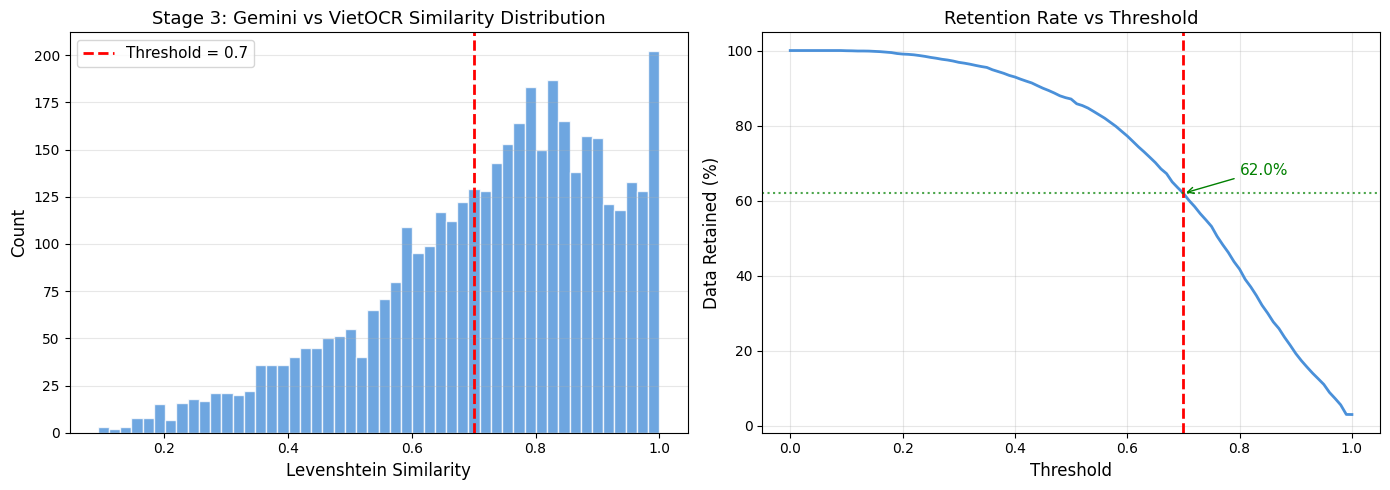

✓ Saved: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/stage3_similarity_distribution.png

PIPELINE SUMMARY
Stage 1: 5103 images (from phase1_filtered_candidates.json)
Stage 3: 2503 images (after VietOCR cross-validation, threshold=0.7)

Final output: /home/khang/Projects/OCR_project/ocr_ai_agent_coding/data/crawled/pseudo_labels_final_clean.txt


In [19]:
# ── Stage 3c: Visualization ──
filtered_phase1 = json.loads(PHASE1_FILTERED_JSON.read_text(encoding="utf-8"))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram
ax = axes[0]
ax.hist(scores, bins=50, color='#4A90D9', edgecolor='white', alpha=0.8)
ax.axvline(x=STAGE3_THRESHOLD, color='red', linestyle='--', linewidth=2,
           label=f'Threshold = {STAGE3_THRESHOLD}')
ax.set_xlabel('Levenshtein Similarity', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Stage 3: Gemini vs VietOCR Similarity Distribution', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Right: Cumulative retention
ax2 = axes[1]
thresholds_range = [i / 100 for i in range(0, 101)]
retention = [sum(1 for s in scores if s >= t) / len(scores) * 100 for t in thresholds_range]
ax2.plot(thresholds_range, retention, color='#4A90D9', linewidth=2)
ax2.axvline(x=STAGE3_THRESHOLD, color='red', linestyle='--', linewidth=2)

th_idx = int(STAGE3_THRESHOLD * 100)
ret_at_th = retention[th_idx]
ax2.axhline(y=ret_at_th, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Data Retained (%)', fontsize=12)
ax2.set_title('Retention Rate vs Threshold', fontsize=13)
ax2.grid(alpha=0.3)
ax2.annotate(
    f'{ret_at_th:.1f}%',
    xy=(STAGE3_THRESHOLD, ret_at_th),
    xytext=(STAGE3_THRESHOLD + 0.1, ret_at_th + 5),
    arrowprops=dict(arrowstyle='->', color='green'),
    fontsize=11, color='green',
)

plt.tight_layout()
plt.savefig(STAGE3_HIST_PNG, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {STAGE3_HIST_PNG}")

# ── Final summary ──
print("\n" + "=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"Stage 1: {len(filtered_phase1)} images (from phase1_filtered_candidates.json)")
# print(f"Stage 2: {len(stage2_kept)} images (after Gemini OCR + quality filter)")
print(f"Stage 3: {len(final_entries)} images (after VietOCR cross-validation, threshold={STAGE3_THRESHOLD})")
print(f"\nFinal output: {STAGE3_FINAL_LABELS}")
print("=" * 60)


- Phân bổ lệch phải (Right-skewed) rõ rệt: Phần lớn các mẫu (cột cao) đều tập trung ở phía nhích về bên phải (điểm similarity từ 0.6 đến 1.0). Đây là một tín hiệu rất tốt. Nó cho thấy mô hình Gemini (gemini-2.5-pro) và mô hình nhận dạng chữ (VietOCR base) phần lớn đồng ý với nhau về nội dung được trích xuất.
- Điểm tụ tập cao ở mức > 0.8: Rất nhiều mẫu có sự tương đồng đặc biệt cao (Levenshtein Similarity ~0.8 - ~0.95+). Điều này khẳng định chữ trong ảnh đủ nét để cả 2 thuật toán đều "nhìn" ra cùng một nội dung, đảm bảo độ tin cậy của nhãn (label).
- Bức tranh tổng thể: Việc hai hệ thống hoàn toàn khác biệt (LLM Vision vs OCR chuyên dụng) cùng cho ra kết quả sát nhau chứng tỏ bộ dữ liệu của bạn có chất lượng nhận dạng nền (baseline) khá ổn, không bị quá lệch (noisy).


=== CÔNG CỤ TINH CHỈNH NGƯỠNG LỌC STAGE 3 ===

=> Tìm thấy 848 ảnh có mức độ tương đồng Gemini-VietOCR trong khoảng [0.7 - 0.8]


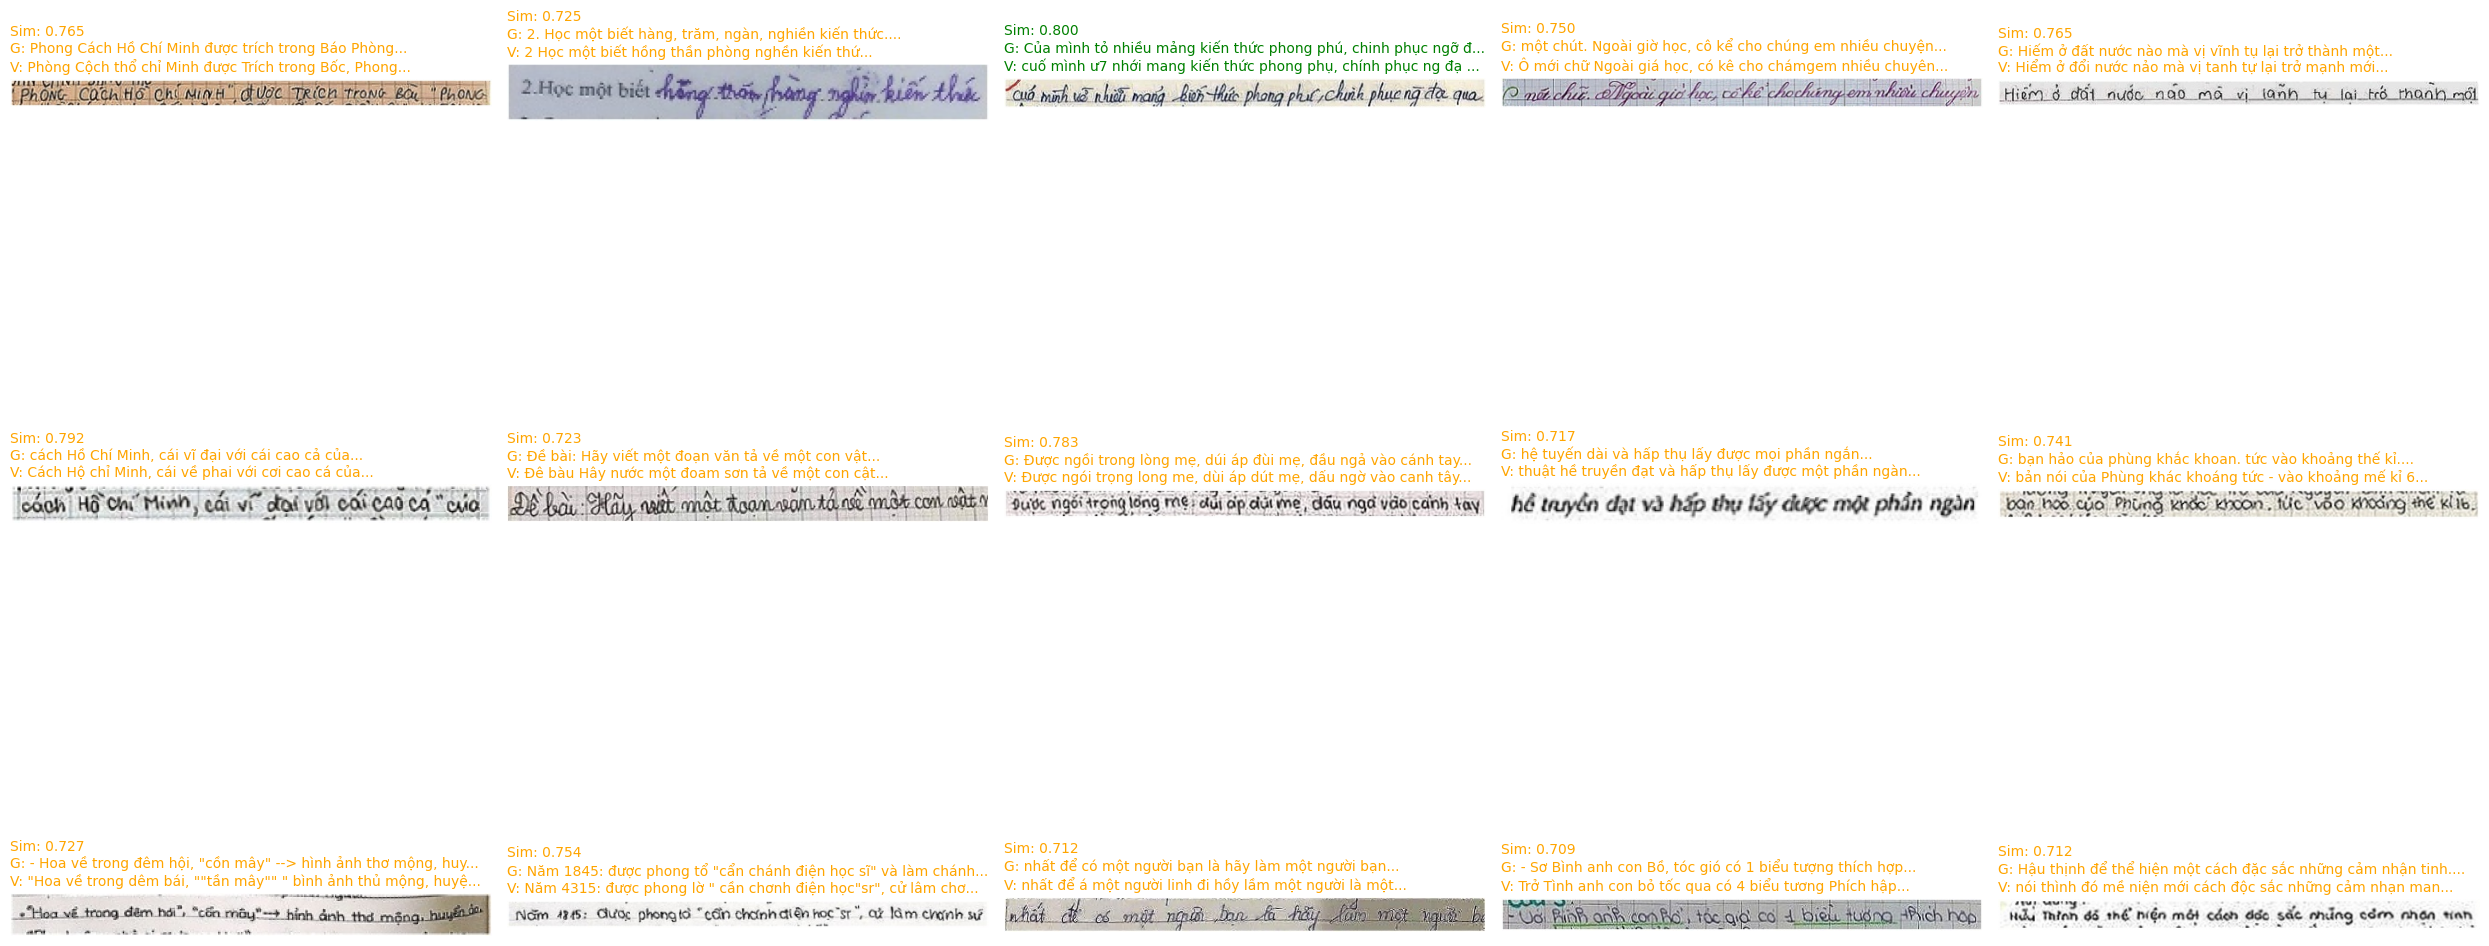

Đã vẽ xong! (Nếu chưa hài lòng, hãy Re-run/Run lại cell này để hiện 15 mẫu khác).


In [27]:
import random
import matplotlib.pyplot as plt
from PIL import Image

print("\n" + "="*50)
print("=== CÔNG CỤ TINH CHỈNH NGƯỠNG LỌC STAGE 3 ===")
print("="*50)

# 1. Nhập khoảng Similarity cần trực quan hóa từ bàn phím (Mặc định 0.4 - 0.5)
try:
    min_val_str = input("Nhập Similarity cần xem TỐI THIỂU (Ví dụ 0.4 - Bỏ trống để dùng 0.4): ")
    min_val = float(min_val_str) if min_val_str.strip() else 0.4
    
    max_val_str = input("Nhập Similarity cần xem TỐI ĐA (Ví dụ 0.5 - Bỏ trống để dùng 0.5): ")
    max_val = float(max_val_str) if max_val_str.strip() else 0.5
except ValueError:
    print("Giá trị không hợp lệ! Mặc định sẽ dùng dải 0.4 -> 0.5")
    min_val, max_val = 0.4, 0.5

# 2. Xử lý logic lọc 
if 'results_with_scores' in locals():
    # Lấy ra các sample nằm trong dải similarity đã chọn
    match_pool = [
        r for r in results_with_scores 
        if min_val <= r['similarity'] <= max_val
    ]
    
    print(f"\n=> Tìm thấy {len(match_pool)} ảnh có mức độ tương đồng Gemini-VietOCR trong khoảng [{min_val} - {max_val}]")
    
    if len(match_pool) > 0:
        # Bốc ngẫu nhiên 15 tấm (nếu có ít hơn 15 tấm thì lấy toàn bộ)
        num_view = 15
        samples = random.sample(match_pool, min(num_view, len(match_pool)))

        # Vẽ lưới hiển thị matplotlib 3 hàng x 5 cột
        plt.figure(figsize=(25, 15))
        for i, item in enumerate(samples):
            # i+1 vì subplot đánh index bắt đầu từ 1
            plt.subplot(3, 5, i + 1)
            
            # Load và show hình
            img = Image.open(item['image_path'])
            plt.imshow(img)
            
            sim_score = item['similarity']
            
            # Khởi tạo title chứa score, Gemini label & VietOCR label 
            # Giới hạn kí tự bằng substring [:40] để không bị vỡ layout
            title = (
                f"Sim: {sim_score:.3f}\n"
                f"G: {item['gemini_label'][:60]}...\n"
                f"V: {item['vietocr_pred'][:60]}..."
            )
            
            # Gợi màu sắc score đánh giá nhanh: Xanh (tốt), Cam (Tạm), Đỏ (Tệ)
            color = 'green' if sim_score >= 0.8 else 'orange' if sim_score >= 0.4 else 'red'
            
            # Set thuộc tính tiêu đề (gốc góc trái)
            plt.title(title, fontsize=10, color=color, loc='left')
            
            # Cất border, trục tọa độ hình ảnh
            plt.axis('off')

        # Fit cho đẹp và ghim hiển thị lên output cell
        plt.tight_layout()
        plt.show()
        print("Đã vẽ xong! (Nếu chưa hài lòng, hãy Re-run/Run lại cell này để hiện 15 mẫu khác).")
    else:
        print("\nKhông có mẫu ảnh nào nằm trong khoảng dải Similarity này! Hãy chạy lại cell và thử dải khác.")

else:
    print("\n⚠ Lỗi: Biến 'results_with_scores' hoàn toàn không tồn tại trong Kernel hiện tại!")
    print("⚠ Cách sửa: Hãy cuộn lên và 'Run' lại cell inference Stage 3a (cell có chứa thanh tiến độ VietOCR) trước khi tiếp tục coi ảnh.")
